# Data Preprocessing

- We will be preprocessing data so the  model can actually learn something useful instead of getting confused.

In [1]:
import pandas as pd
from taxipred.utils.constants import NEW_CSV_PATH

df = pd.read_csv(NEW_CSV_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       901 non-null    float64
 1   time_of_day            902 non-null    object 
 2   day_of_week            905 non-null    object 
 3   traffic_conditions     901 non-null    object 
 4   weather                905 non-null    object 
 5   trip_duration_minutes  905 non-null    float64
 6   trip_price             951 non-null    float64
dtypes: float64(3), object(4)
memory usage: 52.1+ KB


## Separating features and target

In [2]:
X = df.drop(columns=["trip_price"])
y = df["trip_price"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nIncluded features: {list(X.columns)}")

Features shape: (951, 6)
Target shape: (951,)

Included features: ['trip_distance_km', 'time_of_day', 'day_of_week', 'traffic_conditions', 'weather', 'trip_duration_minutes']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Winsorization (Outlier Handling)

**Why after train/test split?**
- Winsorization uses statistics (Q1, Q3, IQR) calculated from the data
- If we calculate these statistics on the entire dataset (including test set), information from the test set leaks into the training process
- **Best practice**: Calculate the threshold on training data only, then apply it to both train and test sets

This ensures the model only learns from training data patterns, making evaluation more realistic.

Text(0.5, 1.0, 'Original Distribution of Trip Price (y_test)')

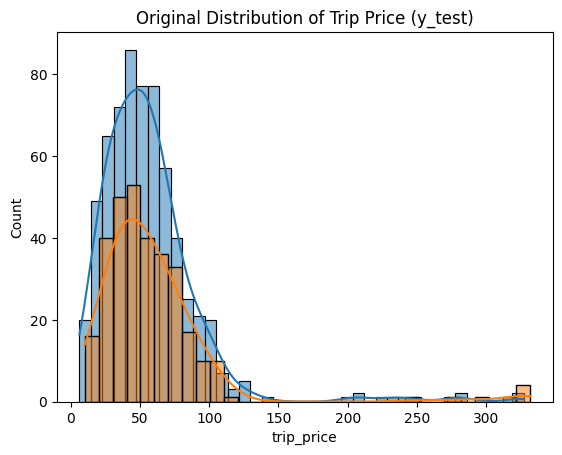

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.histplot(y_train, kde=True)
plt.title("Original Distribution of Trip Price (y_train)")

sns.histplot(y_test, kde=True)
plt.title("Original Distribution of Trip Price (y_test)")

In [5]:
# Calculate winsorization threshold on TRAINING data only
Q3_train = y_train.quantile(0.75)
Q1_train = y_train.quantile(0.25)
IQR_train = Q3_train - Q1_train
upper_threshold = Q3_train + 1.5 * IQR_train

print(f"Winsorization threshold (calculated on training data): {upper_threshold:.2f}")

# Apply the threshold to both train and test sets
y_train_winsorized = y_train.clip(upper=upper_threshold)
y_test_winsorized = y_test.clip(upper=upper_threshold)

print(f"\nOriginal y_train max: {y_train.max():.2f}")
print(f"Winsorized y_train max: {y_train_winsorized.max():.2f}")
print(f"\nOriginal y_test max: {y_test.max():.2f}")
print(f"Winsorized y_test max: {y_test_winsorized.max():.2f}")

# Update y_train and y_test for use in modeling
y_train = y_train_winsorized
y_test = y_test_winsorized

Winsorization threshold (calculated on training data): 121.58

Original y_train max: 327.22
Winsorized y_train max: 121.58

Original y_test max: 332.04
Winsorized y_test max: 121.58


Text(0.5, 1.0, 'Winsorized Distribution of Trip Price (y_test)')

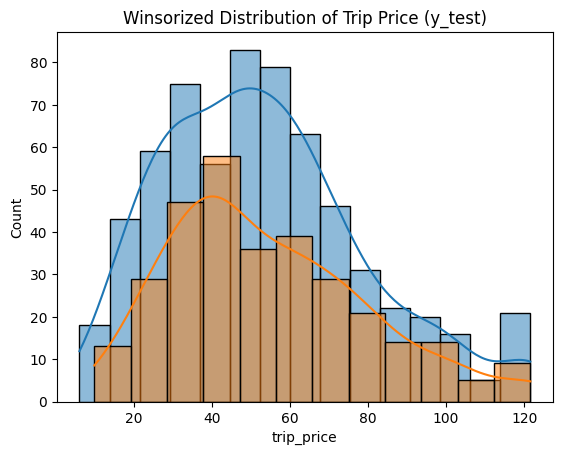

In [6]:
sns.histplot(y_train, kde=True)
plt.title("Winsorized Distribution of Trip Price (y_train)")

sns.histplot(y_test, kde=True)
plt.title("Winsorized Distribution of Trip Price (y_test)")

## Imputation

- Imputing the NaN values with best performing methods based on our evaluations.

In [7]:
numeric_columns = X_train.select_dtypes(include=["number"]).columns
cat_columns = X_train.select_dtypes(include=["object"]).columns

numeric_columns, cat_columns

(Index(['trip_distance_km', 'trip_duration_minutes'], dtype='object'),
 Index(['time_of_day', 'day_of_week', 'traffic_conditions', 'weather'], dtype='object'))

### Numerical Columns
- Using MICE (Multiple Imputation by Chained Equations) to impute null values for numerical columns the performance on our actual data.

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LinearRegression

X_train_num_imp = X_train[numeric_columns].copy()

mice_imputer = IterativeImputer(
    estimator=LinearRegression(),
    random_state=42,
    max_iter=20,
    sample_posterior=False
)

X_train_num_imp = pd.DataFrame(
    mice_imputer.fit_transform(X_train_num_imp),
    columns=X_train_num_imp.columns,
    index=X_train_num_imp.index
)

In [9]:
X_test_num_imp = X_test[numeric_columns].copy()
X_test_num_imp = pd.DataFrame(
    mice_imputer.transform(X_test[numeric_columns]),
    columns=numeric_columns,
    index=X_test.index
)

In [10]:
X_train_num_imp.info(), X_test_num_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 181 to 102
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       637 non-null    float64
 1   trip_duration_minutes  637 non-null    float64
dtypes: float64(2)
memory usage: 14.9 KB
<class 'pandas.core.frame.DataFrame'>
Index: 314 entries, 199 to 891
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       314 non-null    float64
 1   trip_duration_minutes  314 non-null    float64
dtypes: float64(2)
memory usage: 7.4 KB


(None, None)

### Categorical Columns
- Most-frequent imputation will be used for categorical variables because it provides stable and consistently strong performance across categories while avoiding unnecessary model complexity

In [11]:
X_train_cat_imp = X_train[cat_columns].copy()
X_test_cat_imp = X_test[cat_columns].copy()

In [12]:
cat_imputer = SimpleImputer(strategy="most_frequent")


X_train_cat_imp = pd.DataFrame(
    cat_imputer.fit_transform(X_train_cat_imp),
    columns=cat_columns,
    index=X_train.index
)


In [13]:
X_test_cat_imp = pd.DataFrame(
    cat_imputer.transform(X_test_cat_imp),
    columns=cat_columns,
    index=X_test.index
)

In [14]:
# Combine imputed numerical and categorical columns back together
X_train_imputed = pd.concat([X_train_num_imp, X_train_cat_imp], axis=1)
X_test_imputed = pd.concat([X_test_num_imp, X_test_cat_imp], axis=1)

# Ensure columns are in the same order as original
X_train_imputed = X_train_imputed[X_train.columns]
X_test_imputed = X_test_imputed[X_test.columns]

# Verify no missing values
print("Missing values in X_train_imputed:", X_train_imputed.isna().sum().sum())
print("Missing values in X_test_imputed:", X_test_imputed.isna().sum().sum())
X_train_imputed.info(), X_test_imputed.info()

Missing values in X_train_imputed: 0
Missing values in X_test_imputed: 0
<class 'pandas.core.frame.DataFrame'>
Index: 637 entries, 181 to 102
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       637 non-null    float64
 1   time_of_day            637 non-null    object 
 2   day_of_week            637 non-null    object 
 3   traffic_conditions     637 non-null    object 
 4   weather                637 non-null    object 
 5   trip_duration_minutes  637 non-null    float64
dtypes: float64(2), object(4)
memory usage: 34.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 314 entries, 199 to 891
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_distance_km       314 non-null    float64
 1   time_of_day            314 non-null    object 
 2   day_of_week            314 non-null    obje

(None, None)

## Dummies for Categorical Features 

In [15]:
X_train_imputed = pd.get_dummies(X_train_imputed, columns=cat_columns, drop_first=True)
X_test_imputed = pd.get_dummies(X_test_imputed, columns=cat_columns, drop_first=True)

X_train_imputed.shape, X_test_imputed.shape

((637, 10), (314, 10))

In [16]:
X_train_imputed, X_test_imputed = X_train_imputed.align(X_test_imputed, join="left", axis=1, fill_value=0)

X_train_imputed.columns, X_test_imputed.columns

(Index(['trip_distance_km', 'trip_duration_minutes', 'time_of_day_Evening',
        'time_of_day_Morning', 'time_of_day_Night', 'day_of_week_Weekend',
        'traffic_conditions_Low', 'traffic_conditions_Medium', 'weather_Rain',
        'weather_Snow'],
       dtype='object'),
 Index(['trip_distance_km', 'trip_duration_minutes', 'time_of_day_Evening',
        'time_of_day_Morning', 'time_of_day_Night', 'day_of_week_Weekend',
        'traffic_conditions_Low', 'traffic_conditions_Medium', 'weather_Rain',
        'weather_Snow'],
       dtype='object'))

# Testing Models

## Scaling for LR and KNN

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train_imputed)
scaled_X_test = scaler.transform(X_test_imputed)

## Function for Evaluation

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def eval_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return {"MAE": mae, "RMSE": rmse}

def train_predict_eval(X_train_imputed, y_train, X_test_imputed, y_test, model):
    model.fit(X_train_imputed, y_train)
    y_pred = model.predict(X_test_imputed)
    eval = eval_model(y_test, y_pred)
    return eval

## Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_eval = train_predict_eval(scaled_X_train, y_train, scaled_X_test, y_test, lr_model)
lr_eval

{'MAE': 13.207214688170643, 'RMSE': np.float64(17.029267548284295)}

## KNN

**IMPORTANT: Using Cross-Validation for Hyperparameter Tuning**
- We use **cross-validation on the training set** to select the best k value
- This prevents data leakage: the test set is never touched during hyperparameter selection
- The test set is only used once, for final model evaluation after all hyperparameter tuning is complete
- This ensures an unbiased estimate of model performance

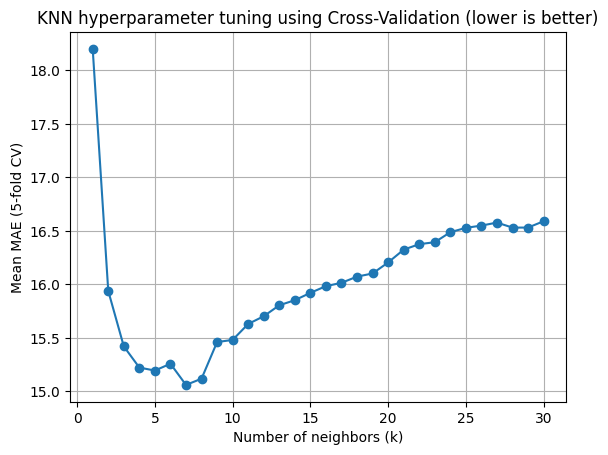


Best k: 7 (CV MAE: 15.0609)


In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

k_values = range(1, 31)
cv_mae_scores = []

# Use cross-validation on TRAINING data only to select best k
# Using 5-fold CV with negative MAE (scoring='neg_mean_absolute_error')
# We take the mean across folds and convert back to positive MAE
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv_scores = cross_val_score(
        knn, 
        scaled_X_train, 
        y_train, 
        cv=5, 
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    # Convert negative MAE back to positive and take mean
    mean_mae = -cv_scores.mean()
    cv_mae_scores.append(mean_mae)

plt.plot(k_values, cv_mae_scores, marker="o")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Mean MAE (5-fold CV)")
plt.title("KNN hyperparameter tuning using Cross-Validation (lower is better)")
plt.grid(True)
plt.show()

# Find best k
best_k = k_values[np.argmin(cv_mae_scores)]
best_mae = min(cv_mae_scores)
print(f"\nBest k: {best_k} (CV MAE: {best_mae:.4f})")

**Decision: 7**

In [21]:
# Train final model with selected k and evaluate on TEST set
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_eval = train_predict_eval(scaled_X_train, y_train, scaled_X_test, y_test, knn_model)
knn_eval

{'MAE': 14.996450955414012, 'RMSE': np.float64(18.871607624958237)}

## Random Forest

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_eval = train_predict_eval(X_train_imputed, y_train, X_test_imputed, y_test, rf_model)
rf_eval


{'MAE': 12.812094557324837, 'RMSE': np.float64(16.442562397590873)}

# Evaluation

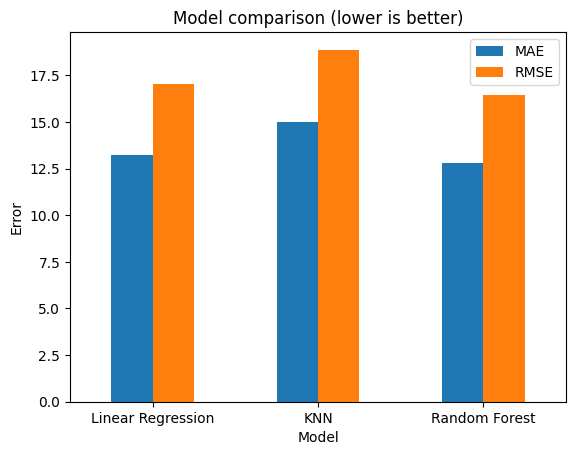

In [23]:
scores = pd.DataFrame({
    "Model": ["Linear Regression", "KNN", "Random Forest"],
    "MAE": [lr_eval["MAE"], knn_eval["MAE"], rf_eval["MAE"]],
    "RMSE": [lr_eval["RMSE"], knn_eval["RMSE"], rf_eval["RMSE"]],
})

scores.set_index("Model").plot(kind="bar")
plt.ylabel("Error")
plt.title("Model comparison (lower is better)")
plt.xticks(rotation=0)
plt.show()

# Conclusion

- Our evaluation results appear to be really close - MAE: 12.81 to 14.99 (difference ~2.18) & RMSE: 16.44 to 18.87 (difference ~2.43)
- These results depend on the following facts:
    - Models are reasonably tuned 
    - The problem is relatively straightforward
    - The dataset is small (951 samples after cleaning)

- After getting "second thoughts" regarding removing the "base_fare", "per_km_rate", "per_minute_rate" columns because of the results, I did another review on the data:
    - The goal is to predict price from trip characteristics (distance, duration, time of day, weather, traffic, etc.), not from the pricing components themselves.
    - Since these columns are directly used in the price calculation, including them would lead to data leakage 

- Since RandomForest has the lowest MAE (12.81) and RMSE (16.44) and it captures non-linear relationships and interactions, which may be useful for this problem: I will be proceeding with **RandomForest**